# Part 1: Import yolo model


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

# Part 2: Load the dataset via YAML file

In [ ]:
import os 

data_path = "/home/somel/code/FYP_Project/Dataset/YOLO/version_7/data.yaml"

if os.path.exists(data_path):
    print("Data file exists.")
    with open(data_path,'r') as f:
        print(f.read())
else:
    print("Data file does not exist.")


# Part 3: Train the model

In [ ]:
model.train(
    data= data_path,
    epochs= 300,
    batch= 16,
    imgsz= 640,
    device= 'cuda'
)

### Resuming Training from previous epoch/checkpoint

In [ ]:
last_checkpoint = "/home/somel/code/FYP_Project/runs/detect/train2/weights/last.pt"
model = YOLO(last_checkpoint)

model.train(
    resume=True
)

# Part 4: Save the model 

In [ ]:
# Save the trained model to 'models' folder within the drive
models_dir = "/home/somel/code/FYP_Project/models/yolo/"
os.makedirs(models_dir, exist_ok=True)

# Find the next available model name
existing_models = [f for f in os.listdir(models_dir) if f.startswith('yolov11_') and f.endswith('.pt')]
next_model_number = len(existing_models) + 1
model_save_path = os.path.join(models_dir, f'yolov11_{next_model_number}_newTilapia.pt')

# Save the model
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Optional: Load pre-trained model

In [ ]:
from ultralytics import YOLO
import os

# Path to your saved model in Google Drive

# training weights model path
# root_path = '/home/somel/code/FYP_Project/runs/detect/train15/weights'
# model_path = os.path.join(root_path, 'best.pt')

# overall model path
root_path = '/home/somel/code/FYP_Project/models/yolo'
model_path = os.path.join(root_path, 'yolov11_13_newTilapia.pt')


# Check if the model file exists before loading
if os.path.exists(model_path):
    model = YOLO(model_path)
    print(f"Successfully loaded model from: {model_path}")
else:
    print(f"Error: Model file not found at {model_path}")

# Part 5: Inferencing


In [ ]:
%matplotlib inline
# Perform inference on an image
import matplotlib.pyplot as plt
import cv2

image_path = '/home/somel/code/FYP_Project/Dataset/YOLO/version_6/test/images/Lates-calcarifer_48_jpg.rf.108d8b3072a7f119c01934d6e902106c.jpg'  # Replace with your image path
results = model.predict(source=image_path)

# Display the results for the first image using matplotlib
result_img = results[0].plot()  # Get the result image as a numpy array
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Optionally save the results for the first image
# results[0].save()

In [ ]:
# Multi-image prediction and visualization
import os
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load the trained model (update path to your best weights)
model = YOLO("/home/somel/code/FYP_Project/runs/detect/train2/weights/last.pt")

# Path to test images folder
test_images_path = "/home/somel/code/FYP_Project/Dataset/YOLO/version_7/test/images"

# Get list of all images in the test folder
all_images = [f for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Randomly select 5 images
num_images = 5
selected_images = random.sample(all_images, min(num_images, len(all_images)))
image_paths = [os.path.join(test_images_path, img) for img in selected_images]

# Run prediction on all selected images
results = model.predict(source=image_paths, conf=0.5)

# Create a figure with subplots (1 row, 5 columns or adjust as needed)
fig, axes = plt.subplots(1, num_images, figsize=(20, 4))

# If only one image, make axes iterable
if num_images == 1:
    axes = [axes]

# Display each prediction result
for idx, (result, ax) in enumerate(zip(results, axes)):
    # Get the plotted image with bounding boxes
    annotated_img = result.plot()
    
    # Convert BGR to RGB for matplotlib
    annotated_img_rgb = annotated_img[:, :, ::-1]
    
    # Display the image
    ax.imshow(annotated_img_rgb)
    ax.set_title(f"Image {idx + 1}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print detection details for each image
print("\n" + "="*50)
print("Detection Summary:")
print("="*50)
for idx, result in enumerate(results):
    print(f"\nImage {idx + 1}: {selected_images[idx]}")
    if len(result.boxes) > 0:
        for box in result.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = result.names[cls]
            print(f"  - {class_name}: {conf:.2%}")
    else:
        print("  - No detections")

In [ ]:
from ultralytics import YOLO
from tabulate import tabulate
# Load your best model
model = YOLO('/home/somel/code/FYP_Project/runs/detect/train15/weights/best.pt')
# Run validation to get per-class metrics
results = model.val(
    data='/home/somel/code/FYP_Project/Dataset/YOLO/version_6/data.yaml',
    split='val',
    conf=0.5,
    iou=0.5
)
# Class names from the model
class_names = list(results.names.values())
# Per-class metrics
table_data = []
for i, cls_name in enumerate(class_names):
    p = results.box.class_result(i)[0]   # Precision
    r = results.box.class_result(i)[1]   # Recall
    ap50 = results.box.class_result(i)[2]  # AP@0.5
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    table_data.append([cls_name, f"{p:.4f}", f"{r:.4f}", f"{f1:.4f}", f"{ap50:.4f}"])
# Overall metrics
overall_p = results.box.mp     # Mean Precision
overall_r = results.box.mr     # Mean Recall
overall_map50 = results.box.map50  # mAP@0.5
overall_f1 = 2 * overall_p * overall_r / (overall_p + overall_r) if (overall_p + overall_r) > 0 else 0
table_data.append(['Overall', f"{overall_p:.4f}", f"{overall_r:.4f}", f"{overall_f1:.4f}", f"{overall_map50:.4f}"])
# Display
headers = ['Class', 'Precision', 'Recall', 'F1', 'mAP@0.5']
print("\n" + "="*60)
print("METRICS SUMMARY")
print("="*60)
print(tabulate(table_data, headers=headers, tablefmt='grid'))
print(f"\nFinal mAP@0.5: {results.box.map50:.4f}")
print(f"Final mAP@0.5:0.95: {results.box.map:.4f}")

# Optional


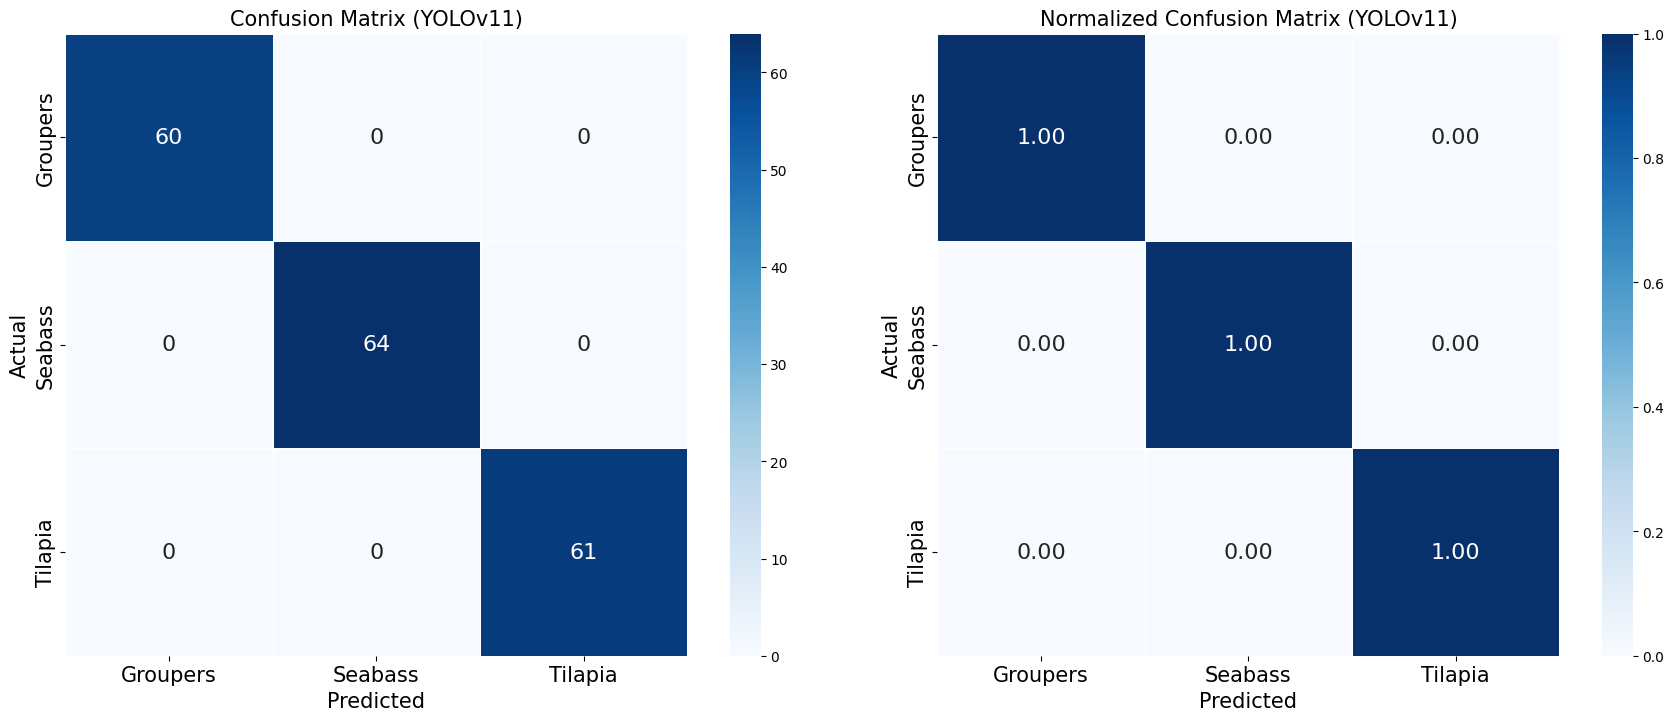

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Raw YOLO confusion matrix (rows = predicted, columns = true)
full_matrix = np.array([
    [60,  0,  0,  7],   # Groupers predicted
    [ 0, 64,  0,  0],   # Seabass predicted
    [ 0,  0, 61,  4],   # Tilapia predicted
    [ 4,  1,  1,  0],   # background predicted
])

# Remove the background row and column (last row & last column)
class_names = ['Groupers', 'Seabass', 'Tilapia']
cm = full_matrix[:3, :3]  # 3x3 matrix without background

# Transpose so rows = True (Actual), columns = Predicted
cm = cm.T

# Normalized version (row-normalized = normalize by actual class)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Plot (Counts + Normalized side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: Regular confusion matrix (counts)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 16}, ax=ax1,square=True)
ax1.xaxis.set_ticks_position('bottom')
ax1.xaxis.set_label_position('bottom')
ax1.set_xlabel('Predicted', fontsize=15)
ax1.set_ylabel('Actual', fontsize=15)
ax1.set_title('Confusion Matrix (YOLOv11)', fontsize=15)
ax1.tick_params(axis='both', labelsize=15)
plt.sca(ax1)

# Right: Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 16}, ax=ax2, vmin=0, vmax=1,square=True)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.set_xlabel('Predicted', fontsize=15)
ax2.set_ylabel('Actual', fontsize=15)
ax2.set_title('Normalized Confusion Matrix (YOLOv11)', fontsize=15)
ax2.tick_params(axis='both', labelsize=15)
plt.sca(ax2)

plt.tight_layout()
plt.savefig('runs/detect/train2/confusion_matrix_no_bg.png', dpi=150, bbox_inches='tight')
plt.show()

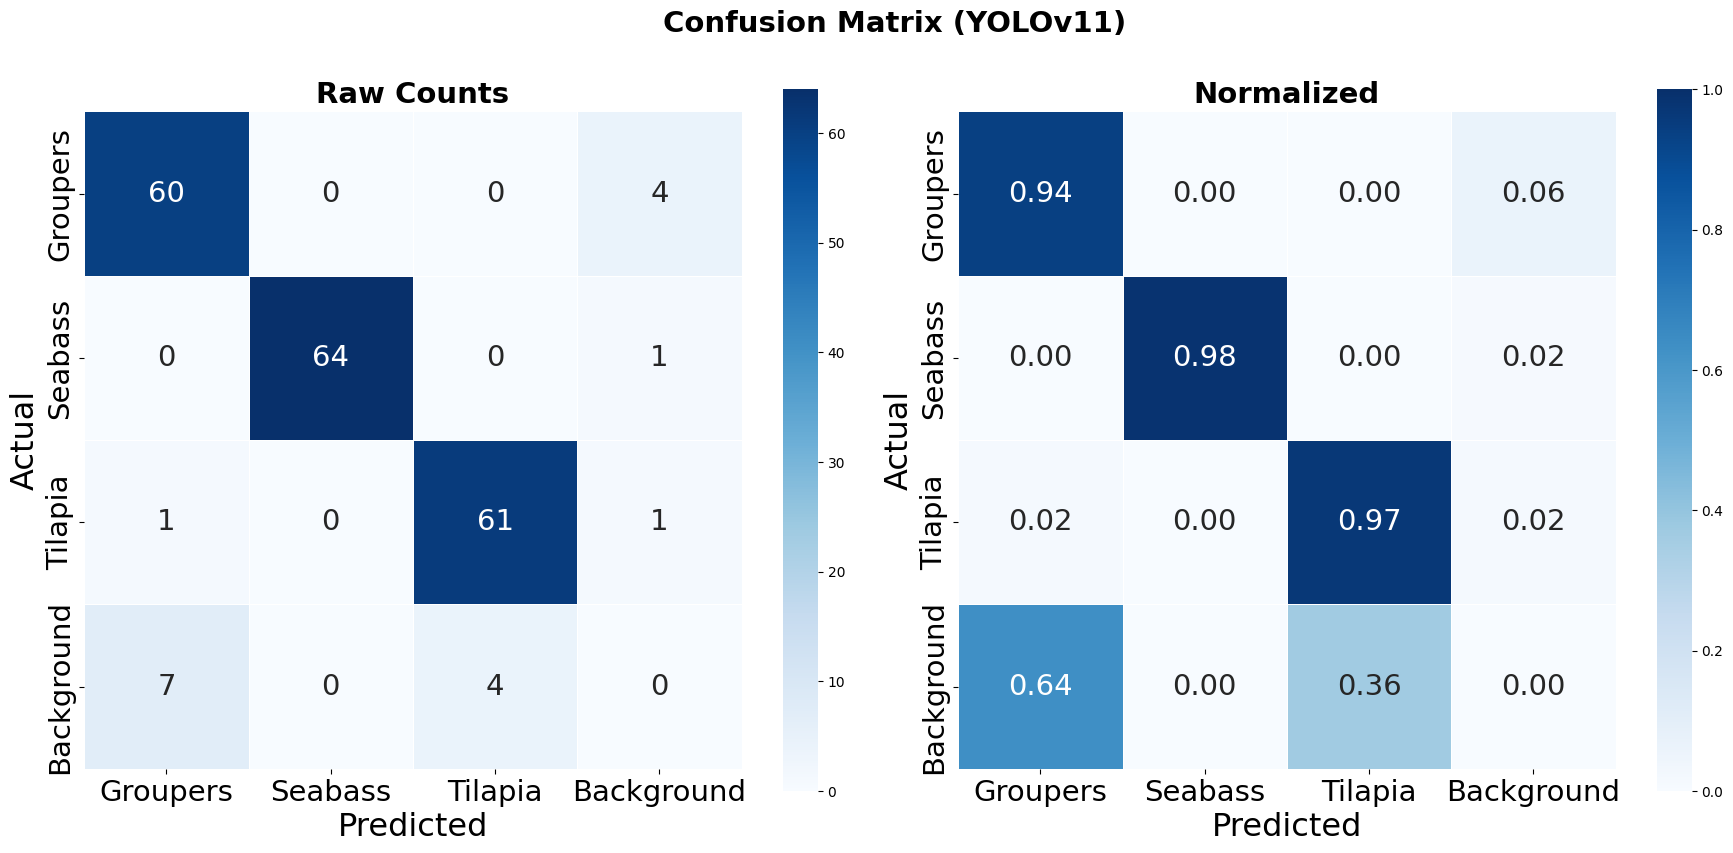

Confusion matrix with background saved!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Raw YOLO confusion matrix (rows = predicted, columns = true)
full_matrix = np.array([
    [60,  0,  1,  7],   # Groupers predicted
    [ 0, 64,  0,  0],   # Seabass predicted
    [ 0,  0, 61,  4],   # Tilapia predicted
    [ 4,  1,  1,  0],   # background predicted
])

# Keep ALL rows and columns (including background)
class_names_with_bg = ['Groupers', 'Seabass', 'Tilapia', 'Background']
cm = full_matrix.T  # Transpose so rows = Actual, columns = Predicted

# Normalized version (row-normalized = normalize by actual class)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)  # Handle division by zero

# Plot (Counts + Normalized side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Confusion Matrix (YOLOv11)', fontsize=21, fontweight='bold', y=1.02)
# Left: Raw counts
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names_with_bg, 
    yticklabels=class_names_with_bg,
    linewidths=0.5, 
    linecolor='white',
    annot_kws={"size": 21}, 
    ax=ax1, 
    square=True,
    )

ax1.set_xlabel('Predicted', fontsize=23)
ax1.set_ylabel('Actual', fontsize=23)
ax1.set_title('Raw Counts', fontsize=21, fontweight='bold')
ax1.tick_params(axis='both', labelsize=21)


# Right: Normalized
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    xticklabels=class_names_with_bg, 
    yticklabels=class_names_with_bg,
    linewidths=0.5, 
    linecolor='white',
    annot_kws={"size": 21}, 
    ax=ax2, 
    vmin=0, 
    vmax=1, 
    square=True,
    )

ax2.set_xlabel('Predicted', fontsize=23)
ax2.set_ylabel('Actual', fontsize=23)
ax2.set_title('Normalized', fontsize=21, fontweight='bold')
ax2.tick_params(axis='both', labelsize=21)

plt.tight_layout()
plt.savefig('runs/detect/train15/confusion_matrix_with_bg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix with background saved!")

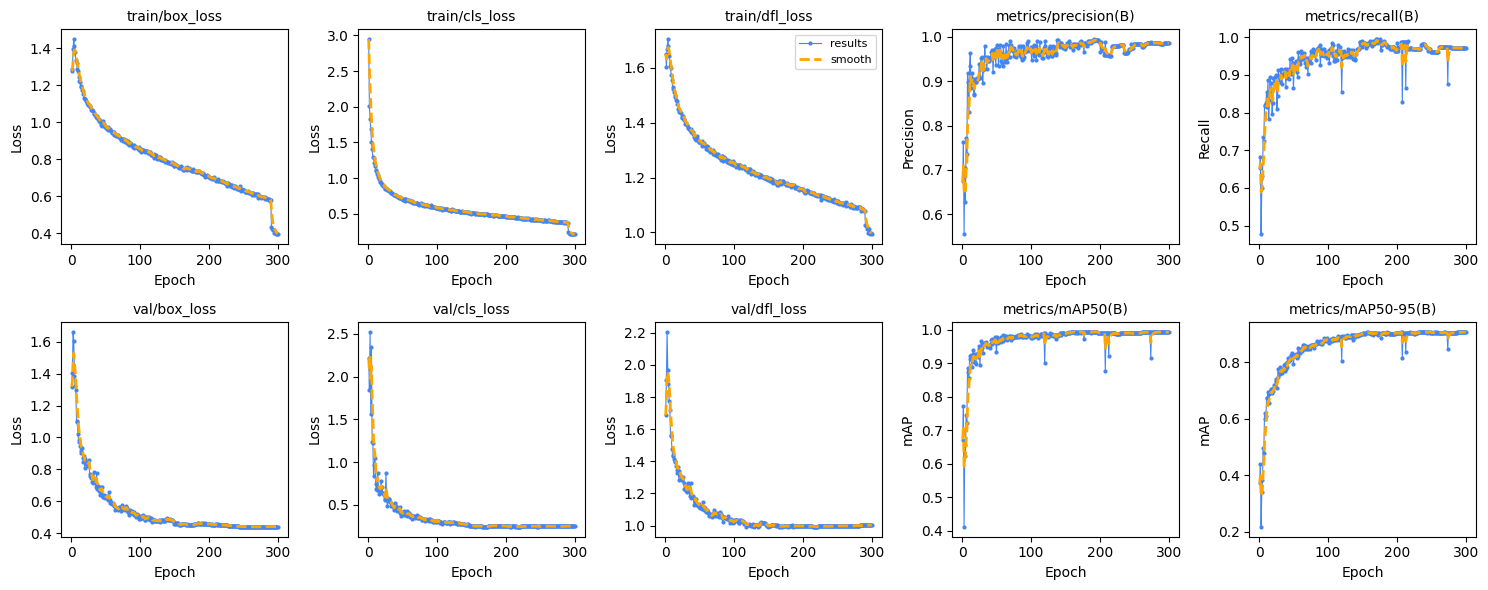

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.read_csv('/home/somel/code/FYP_Project/runs/detect/train15/results.csv', skipinitialspace=True)

def smooth(y, weight=0.6):
    last = y.values[0]
    smoothed = []
    for v in y.values:
        smoothed_val = last * weight + (1 - weight) * v
        last = smoothed_val
        smoothed.append(smoothed_val)
    return np.array(smoothed)

plots = [
    ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)'],
    ['val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
]

ylabels = [
    ['Loss', 'Loss', 'Loss', 'Precision', 'Recall'],
    ['Loss', 'Loss', 'Loss', 'mAP', 'mAP']
]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row_idx, row in enumerate(plots):
    for col_idx, col_name in enumerate(row):
        ax = axes[row_idx, col_idx]
        x = results['epoch']
        y = results[col_name]
        
        ax.plot(x, y, 'o-', color='#4285F4', markersize=2, linewidth=0.8, label='results')
        ax.plot(x, smooth(y), '--', color='orange', linewidth=2, label='smooth')
        
        ax.set_title(col_name, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabels[row_idx][col_idx])
        
        if row_idx == 0 and col_idx == 2:
            ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('yolo11_training_results.png', dpi=200, bbox_inches='tight')
plt.show()